# 01 — Discovery : FAERS Drug Hospitalization Dataset

**Module :** Machine Learning — Phase 1  
**Auteurs :** Amine El Biyadi / Aya Raissouni / Douae Moeniss  
**Date :** Mai 2026  
**Encadrant :** Pr. Y. EL YOUNOUSSI  

---

**Objectif de ce notebook :**  
Charger le dataset FAERS collecté via l'API openFDA, vérifier qu'il respecte toutes les contraintes du projet (taille, types de variables, déséquilibre des classes), et produire une exploration visuelle confirmant que le dataset est exploitable pour la Phase 2.

**Livrables couverts (Section 4 du PDF) :**
- `df.info()` — types et valeurs manquantes par colonne
- `df.describe()` — statistiques descriptives
- `df.head()` — aperçu des premières lignes
- Vérification du déséquilibre : `value_counts` + graphique


## 1. Imports, configuration et chargement du dataset

In [89]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Unified style — seaborn only, no plt.style conflict (fix #5)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

PALETTE = ["#4C72B0", "#E47DC2"]

# ── Dataset path — adjust if needed
DATASET_PATH = "../data/dataset.csv"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : {DATASET_PATH}\n"
        "Lancez d'abord : python src/data_collection.py"
    )

df = pd.read_csv(DATASET_PATH)

# ── Explicit column lists (fix #4 — prevents categorical-as-int
#    from polluting numeric operations like corr() or describe())
NUMERIC_COLS = [
    "patient_age",
    "nb_drugs",
    "nb_reactions",
    "worst_reaction_outcome",
    "nb_suspect_drugs",
]
CATEGORICAL_COLS = [
    "patient_sex",
    "reporter_qualification",
    "route_of_admin",
    "country",
    "has_black_box_warning",
    "is_concomitant_present",
]
TARGET_COL = "seriousnesshospitalization"

# ── Cast categoricals properly so they never appear in numeric ops
for col in CATEGORICAL_COLS + [TARGET_COL]:
    if col in df.columns:
        df[col] = df[col].astype("category")

print(f"Dataset chargé — {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Versions : pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")


Dataset chargé — 10,200 lignes × 12 colonnes
Versions : pandas 2.3.3 | numpy 2.3.5 | seaborn 0.13.2


## 2. Structure du dataset — `df.info()`

Vérifie les types de chaque colonne et le nombre de valeurs non-nulles.  
Les colonnes catégorielles doivent apparaître en type `category`,  
les numériques en `float64` ou `int64`.


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   patient_age                 6775 non-null   float64 
 1   nb_drugs                    10200 non-null  int64   
 2   nb_reactions                10200 non-null  int64   
 3   worst_reaction_outcome      9538 non-null   float64 
 4   nb_suspect_drugs            10200 non-null  int64   
 5   patient_sex                 10125 non-null  category
 6   reporter_qualification      9868 non-null   category
 7   route_of_admin              8014 non-null   category
 8   country                     9662 non-null   category
 9   has_black_box_warning       10200 non-null  category
 10  is_concomitant_present      10200 non-null  category
 11  seriousnesshospitalization  10200 non-null  category
dtypes: category(7), float64(2), int64(3)
memory usage: 472.9 KB


## 3. Aperçu des premières lignes — `df.head()`

Permet de vérifier visuellement la structure, les noms de colonnes,  
et la cohérence des valeurs brutes avant toute analyse.


In [91]:
df.head(10)

,patient_age,nb_drugs,nb_reactions,worst_reaction_outcome,nb_suspect_drugs,patient_sex,reporter_qualification,route_of_admin,country,has_black_box_warning,is_concomitant_present,seriousnesshospitalization
0,26.0,1,2,NaN,1,1.0,3.0,41.0,NaN,0,0,0
1,77.0,1,4,NaN,1,2.0,5.0,42.0,NaN,0,0,0
2,NaN,1,2,NaN,1,2.0,5.0,NaN,NaN,0,0,0
3,NaN,1,1,6.0,1,1.0,5.0,NaN,US,0,0,0
4,NaN,9,1,6.0,9,2.0,1.0,NaN,US,1,0,0
5,48.0,6,1,6.0,6,2.0,1.0,NaN,US,1,0,0
6,68.0,2,2,6.0,2,2.0,5.0,48.0,US,0,0,0
7,65.0,3,1,6.0,2,2.0,1.0,48.0,US,0,1,0
8,59.0,2,2,6.0,2,2.0,1.0,48.0,US,0,0,0
9,42.0,2,1,1.0,2,1.0,5.0,NaN,US,0,0,0


## 4. Statistiques descriptives — `df.describe()`

### 4a. Variables numériques

Points à observer :
- `patient_age` : plage attendue 0–120 ans, médiane autour de 50–60
- `nb_drugs` : fortement asymétrique à droite (outliers possibles)
- `worst_reaction_outcome` : entre 1 et 6, valeurs manquantes attendues
- `nb_suspect_drugs` : toujours ≤ `nb_drugs`


In [92]:
df[NUMERIC_COLS].describe().round(2)

,patient_age,nb_drugs,nb_reactions,worst_reaction_outcome,nb_suspect_drugs
count,6775.00,10200.00,10200.00,9538.00,10200.00
mean,81.39,3.23,2.67,4.91,1.72
std,753.78,3.86,3.13,1.77,1.54
min,0.00,1.00,1.00,1.00,1.00
25%,47.00,1.00,1.00,3.00,1.00
50%,61.00,2.00,2.00,6.00,1.00
75%,72.00,4.00,3.00,6.00,2.00
max,32193.00,88.00,60.00,6.00,32.00


### 4b. Variables catégorielles

Points à observer :
- `patient_sex` : modalités 0, 1, 2 — la plus fréquente doit dominer
- `reporter_qualification` : 1=médecin, 5=consommateur sont les plus fréquents dans FAERS
- `country` : US représente habituellement ~60–70 % des rapports FAERS
- `has_black_box_warning` et `is_concomitant_present` : binaires (0/1)


In [93]:
df[CATEGORICAL_COLS + [TARGET_COL]].describe()

,patient_sex,reporter_qualification,route_of_admin,country,has_black_box_warning,is_concomitant_present,seriousnesshospitalization
count,10125.0,9868.0,8014.0,9662,10200,10200,10200
unique,3.0,5.0,30.0,75,2,2,2
top,2.0,5.0,48.0,US,0,0,0
freq,5917.0,4918.0,4926.0,7461,7193,6618,8279


## 5. Vérification automatique des contraintes — Section 2.3 du PDF

Chaque exigence obligatoire est contrôlée programmatiquement.


In [94]:
n_rows          = len(df)
n_features      = df.shape[1] - 1
minority_ratio  = (df[TARGET_COL].cat.codes == 1).mean()
n_num           = len(NUMERIC_COLS)
n_cat           = len(CATEGORICAL_COLS)

checks = [
    ("Type de tâche",              "Classification supervisée binaire",           True),
    ("Taille totale >= 10 000",    f"{n_rows:,} lignes",                          n_rows >= 10_000),
    ("Nombre de features >= 8",    f"{n_features} features",                      n_features >= 8),
    ("Classe minoritaire 5 %–25 %",f"{minority_ratio*100:.1f} %",                 0.05 <= minority_ratio <= 0.25),
    ("Variables numériques",       f"{n_num} colonnes",                           n_num >= 1),
    ("Variables catégorielles",    f"{n_cat} colonnes",                           n_cat >= 1),
    ("Source API publique gratuite","openFDA FAERS + Drug Label",                 True),
    ("Déséquilibre naturel",       "Pas de manipulation artificielle",            True),
]

print("=" * 62)
print("  VÉRIFICATION DES CONTRAINTES — SECTION 2.3 DU PDF")
print("=" * 62)
all_ok = True
for label, value, ok in checks:
    icon = "✅" if ok else "❌"
    print(f"  {icon}  {label:<38} {value}")
    if not ok:
        all_ok = False
print("=" * 62)
print(f"  {'TOUTES LES CONTRAINTES RESPECTÉES ✅' if all_ok else 'CONTRAINTES NON RESPECTÉES ❌'}")
print("=" * 62)


  VÉRIFICATION DES CONTRAINTES — SECTION 2.3 DU PDF
  ✅  Type de tâche                          Classification supervisée binaire
  ✅  Taille totale >= 10 000                10,200 lignes
  ✅  Nombre de features >= 8                11 features
  ✅  Classe minoritaire 5 %–25 %            18.8 %
  ✅  Variables numériques                   5 colonnes
  ✅  Variables catégorielles                6 colonnes
  ✅  Source API publique gratuite           openFDA FAERS + Drug Label
  ✅  Déséquilibre naturel                   Pas de manipulation artificielle
  TOUTES LES CONTRAINTES RESPECTÉES ✅


## 6. Analyse des valeurs manquantes

Les valeurs manquantes sont attendues sur `patient_age` (champ optionnel dans FAERS),  
`worst_reaction_outcome` (non renseigné si aucune issue déclarée),  
et `route_of_admin` (facultatif dans le rapport).  
Elles seront traitées par imputation en Phase 2.


In [95]:
missing_n   = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_n / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    "Manquants (n)":   missing_n,
    "Manquants (%)":   missing_pct,
})
print(missing_df.to_string())


                            Manquants (n)  Manquants (%)
patient_age                          3425           33.6
route_of_admin                       2186           21.4
worst_reaction_outcome                662            6.5
country                               538            5.3
reporter_qualification                332            3.3
patient_sex                            75            0.7
nb_drugs                                0            0.0
nb_reactions                            0            0.0
nb_suspect_drugs                        0            0.0
has_black_box_warning                   0            0.0
is_concomitant_present                  0            0.0
seriousnesshospitalization              0            0.0


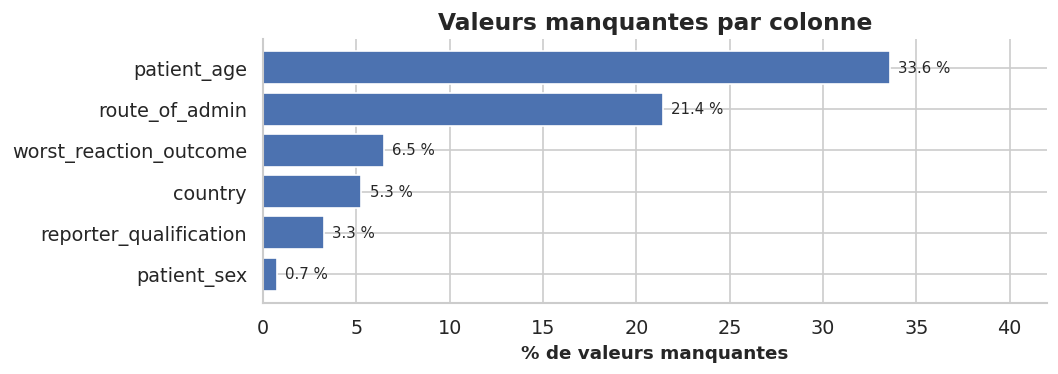

Graphique sauvegardé → missing_values.png


In [96]:
cols_with_missing = missing_n[missing_n > 0]

if cols_with_missing.empty:
    print("Aucune valeur manquante détectée.")
else:
    pct_vals = (cols_with_missing / len(df) * 100).sort_values()
    fig, ax = plt.subplots(figsize=(9, max(3, len(pct_vals) * 0.55)))
    bars = ax.barh(pct_vals.index, pct_vals.values, color="#4C72B0", edgecolor="white")
    ax.bar_label(bars, fmt="%.1f %%", padding=5, fontsize=9)
    ax.set_xlabel("% de valeurs manquantes")
    ax.set_title("Valeurs manquantes par colonne")
    ax.set_xlim(0, min(100, pct_vals.max() * 1.25))
    plt.tight_layout()
    plt.savefig("missing_values.png", bbox_inches="tight")
    plt.show()
    print("Graphique sauvegardé → missing_values.png")


## 7. Distribution de la variable cible — `seriousnesshospitalization`

**Exigence PDF Section 4 :** `value_counts` + graphique confirmant le déséquilibre naturel des classes.


In [97]:
target_int = df[TARGET_COL].cat.codes
counts     = target_int.value_counts().sort_index()
ratios     = target_int.value_counts(normalize=True).sort_index() * 100

print("── value_counts ─────────────────────────────────────────────")
print(f"  seriousnesshospitalization = 0 (non hospitalisé) : {counts.get(0,0):>6}  ({ratios.get(0,0):.1f} %)")
print(f"  seriousnesshospitalization = 1 (hospitalisé)     : {counts.get(1,0):>6}  ({ratios.get(1,0):.1f} %)")
print(f"  Total                                            : {len(df):>6}")
print()
constraint_ok = 0.05 <= ratios.get(1,0)/100 <= 0.25
print(f"  Ratio classe minoritaire : {ratios.get(1,0):.2f} %")
print(f"  Contrainte 5 %–25 %      : {'✅ Respectée' if constraint_ok else '❌ Non respectée'}")


── value_counts ─────────────────────────────────────────────
  seriousnesshospitalization = 0 (non hospitalisé) :   8279  (81.2 %)
  seriousnesshospitalization = 1 (hospitalisé)     :   1921  (18.8 %)
  Total                                            :  10200

  Ratio classe minoritaire : 18.83 %
  Contrainte 5 %–25 %      : ✅ Respectée


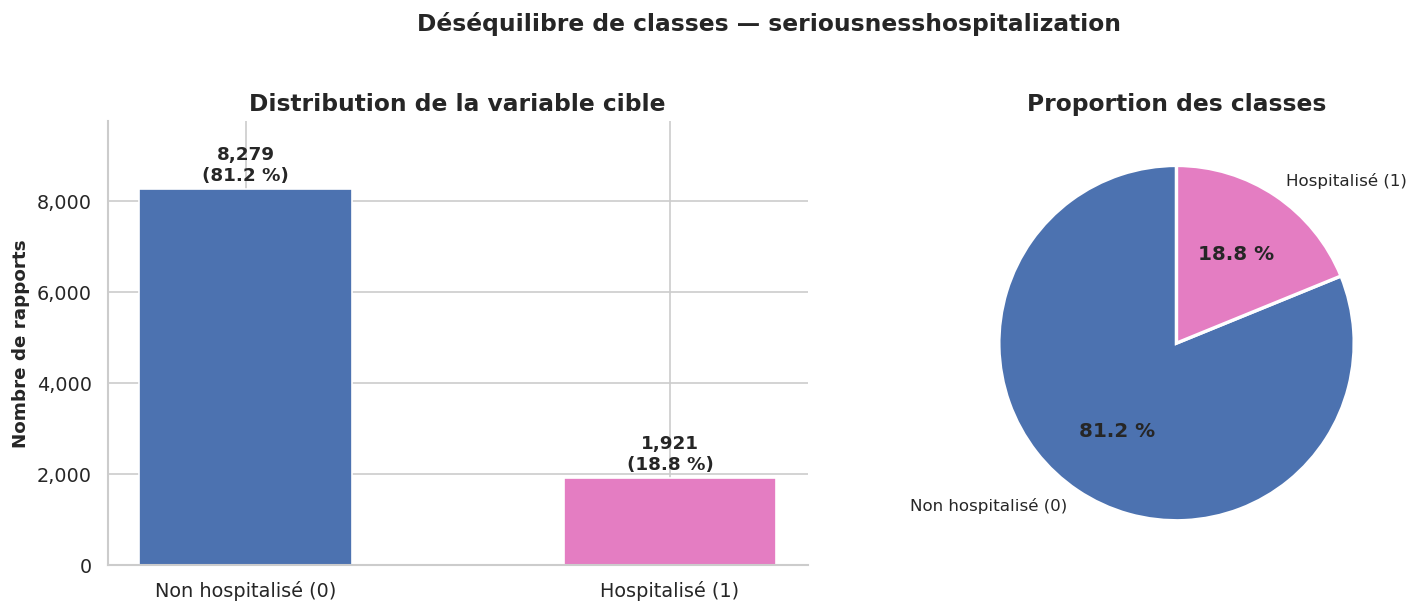

Graphique sauvegardé → class_distribution.png


In [98]:
labels = ["Non hospitalisé (0)", "Hospitalisé (1)"]
values = [counts.get(0, 0), counts.get(1, 0)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Bar chart
ax = axes[0]
bars = ax.bar(labels, values, color=PALETTE, edgecolor="white", width=0.5)
for bar, val, ratio in zip(bars, values, [ratios.get(0,0), ratios.get(1,0)]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.012,
        f"{val:,}\n({ratio:.1f} %)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
ax.set_title("Distribution de la variable cible")
ax.set_ylabel("Nombre de rapports")
ax.set_ylim(0, max(values) * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    values, labels=labels, colors=PALETTE, autopct="%1.1f %%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(12)
ax2.set_title("Proportion des classes")

plt.suptitle(
    "Déséquilibre de classes — seriousnesshospitalization",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("class_distribution.png", bbox_inches="tight")
plt.show()
print("Graphique sauvegardé → class_distribution.png")


## 8. Distribution des variables numériques

La ligne verticale orange représente la médiane de chaque variable.  
Les distributions très asymétriques (`nb_drugs`, `nb_reactions`) signalent  
des outliers à traiter en Phase 2.


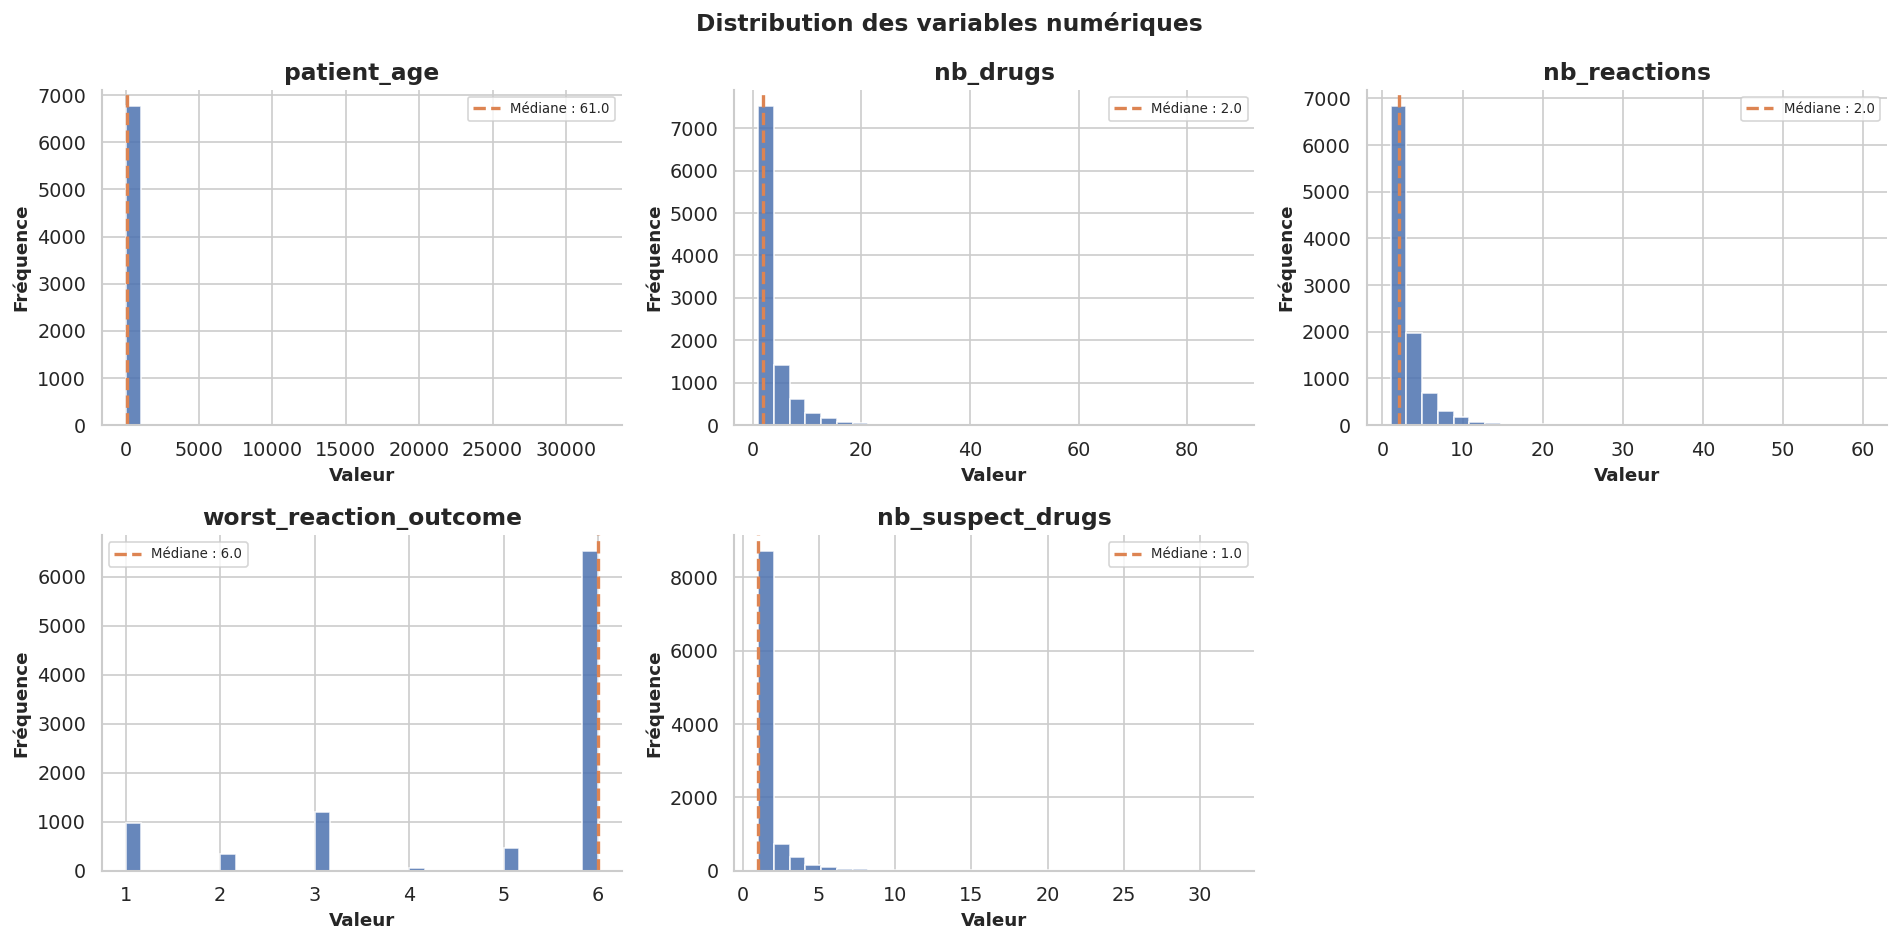

Graphique sauvegardé → numeric_distributions.png


In [99]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
    median_val = data.median()
    ax.axvline(median_val, color="#DD8452", linestyle="--", linewidth=2,
               label=f"Médiane : {median_val:.1f}")
    ax.set_title(col)
    ax.set_xlabel("Valeur")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=8)

for j in range(len(NUMERIC_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables numériques", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("numeric_distributions.png", bbox_inches="tight")
plt.show()
print("Graphique sauvegardé → numeric_distributions.png")


## 9. Distribution des variables catégorielles

Seules les 12 modalités les plus fréquentes sont affichées par variable  
(utile pour `route_of_admin` et `country` à haute cardinalité).


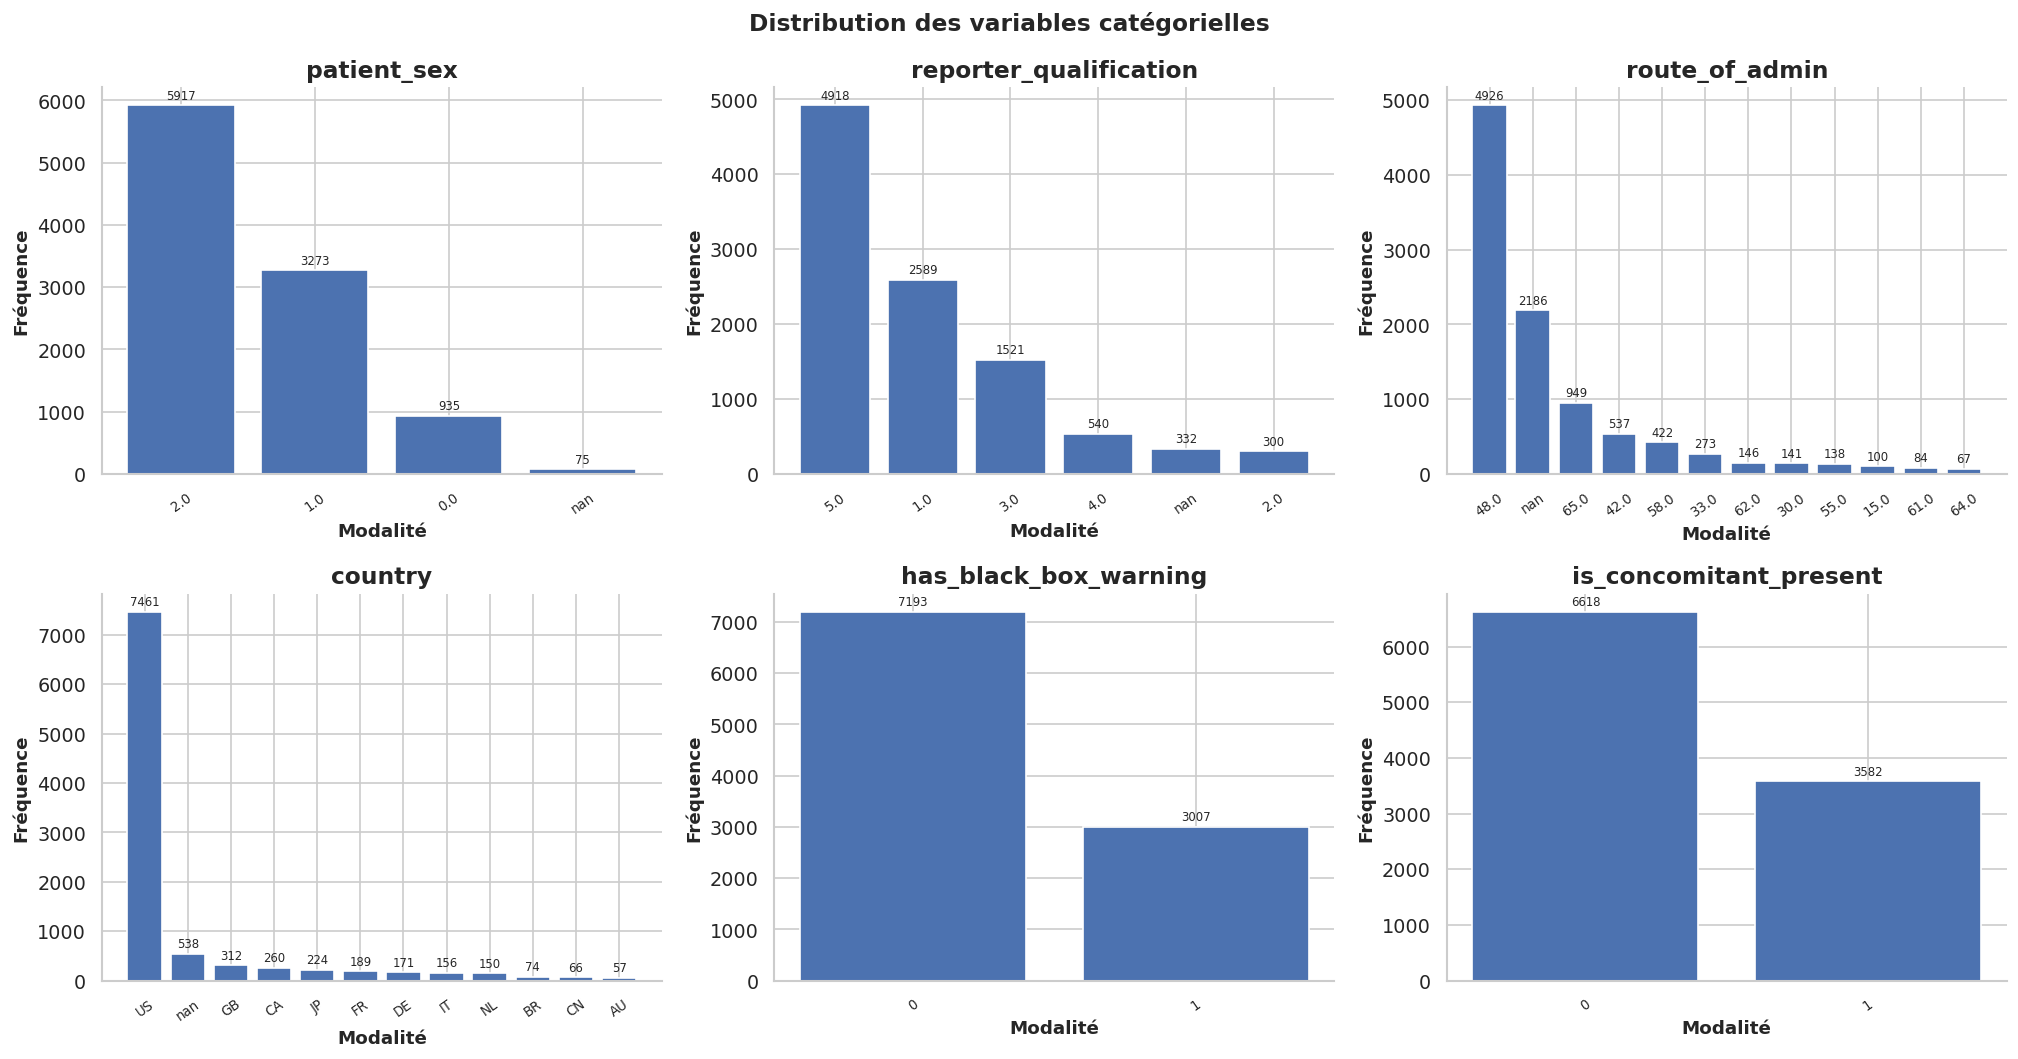

Graphique sauvegardé → categorical_distributions.png


In [100]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    ax = axes[i]
    counts_cat = df[col].astype(str).value_counts().head(12)
    bars = ax.bar(counts_cat.index, counts_cat.values,
                  color="#4C72B0", edgecolor="white")
    ax.bar_label(bars, fontsize=7, padding=2)
    ax.set_title(col)
    ax.set_xlabel("Modalité")
    ax.set_ylabel("Fréquence")
    ax.tick_params(axis="x", rotation=35, labelsize=8)

for j in range(len(CATEGORICAL_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables catégorielles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("categorical_distributions.png", bbox_inches="tight")
plt.show()
print("Graphique sauvegardé → categorical_distributions.png")


## 10. Analyse du coût asymétrique — justification du choix de métrique

**Exigence PDF Section 3.2c :** chiffrer l'asymétrie FP / FN pour justifier la métrique principale.


In [101]:
cout_faux_negatif = 15_000  # € — hospitalisation réelle non détectée
# Justification : séjour hospitalier moyen 3–5 jours (~3 000 €/jour en coût système de santé),
# plus conséquences médicales, juridiques, et humaines d'une revue tardive.

cout_faux_positif = 50  # € — fausse alerte traitée inutilement
# Justification : revue manuelle de ~30 min par un pharmacovigilant.
# Salaire chargé estimé à ~100 €/h → 50 € par fausse alerte.

ratio = cout_faux_negatif / cout_faux_positif

print("─" * 45)
print("  Analyse du coût asymétrique")
print("─" * 45)
print(f"  Faux négatif (FN) : {cout_faux_negatif:>8,} €")
print(f"  Faux positif (FP) : {cout_faux_positif:>8,} €")
print(f"  Ratio FN / FP     : {ratio:>8.0f}x")
print("─" * 45)
print()
print("Conclusion : rater une hospitalisation réelle coûte")
print(f"{ratio:.0f}x plus cher que générer une fausse alerte.")
print()
print("→ Métrique principale retenue : RECALL")
print("  (minimise les faux négatifs)")
print()
print("→ Métriques secondaires : F1-score, PR-AUC")
print()
print("→ Métrique refusée : Accuracy seule")
minority_pct = df[TARGET_COL].cat.codes.mean() * 100
print(f"  Un modèle naïf 'toujours 0' atteindrait {100-minority_pct:.1f}% d'accuracy")
print(f"  mais aurait Recall = 0% sur la classe hospitalisée.")


─────────────────────────────────────────────
  Analyse du coût asymétrique
─────────────────────────────────────────────
  Faux négatif (FN) :   15,000 €
  Faux positif (FP) :       50 €
  Ratio FN / FP     :      300x
─────────────────────────────────────────────

Conclusion : rater une hospitalisation réelle coûte
300x plus cher que générer une fausse alerte.

→ Métrique principale retenue : RECALL
  (minimise les faux négatifs)

→ Métriques secondaires : F1-score, PR-AUC

→ Métrique refusée : Accuracy seule
  Un modèle naïf 'toujours 0' atteindrait 81.2% d'accuracy
  mais aurait Recall = 0% sur la classe hospitalisée.


## 11. Bilan final — Dataset exploitable pour la Phase 2 ?


In [102]:
n_rows         = len(df)
n_features     = df.shape[1] - 1
minority_pct   = df[TARGET_COL].cat.codes.mean() * 100
missing_max    = df.isna().mean().max() * 100
n_duplicates   = df.duplicated().sum()

bilan = [
    ("Taille",                       f"{n_rows:,} lignes",                              n_rows >= 10_000),
    ("Features",                     f"{n_features} ({len(NUMERIC_COLS)} num. + {len(CATEGORICAL_COLS)} cat.)", n_features >= 8),
    ("Classe minoritaire",           f"{minority_pct:.1f} %",                           0.05 <= minority_pct/100 <= 0.25),
    ("Déséquilibre naturel",         "Oui — pas de manipulation artificielle",           True),
    ("Types mixtes",                 f"{len(NUMERIC_COLS)} numériques + {len(CATEGORICAL_COLS)} catégorielles", True),
    ("Source API publique",          "openFDA FAERS + Drug Label",                       True),
    ("Doublons",                     f"{n_duplicates} doublons détectés",               n_duplicates == 0),
    ("Valeurs manquantes (max col)", f"{missing_max:.1f} %",                            missing_max < 80),
    ("Cible sans fuite de données",  "Champs seriousness* exclus des features",         True),
]

print("=" * 65)
print("  BILAN FINAL — EXPLOITABILITÉ DU DATASET")
print("=" * 65)
all_ok = True
for label, value, ok in bilan:
    icon = "✅" if ok else "❌"
    print(f"  {icon}  {label:<42} {value}")
    if not ok:
        all_ok = False
print("=" * 65)


  BILAN FINAL — EXPLOITABILITÉ DU DATASET
  ✅  Taille                                     10,200 lignes
  ✅  Features                                   11 (5 num. + 6 cat.)
  ✅  Classe minoritaire                         18.8 %
  ✅  Déséquilibre naturel                       Oui — pas de manipulation artificielle
  ✅  Types mixtes                               5 numériques + 6 catégorielles
  ✅  Source API publique                        openFDA FAERS + Drug Label
  ❌  Doublons                                   2042 doublons détectés
  ✅  Valeurs manquantes (max col)               33.6 %
  ✅  Cible sans fuite de données                Champs seriousness* exclus des features
